# Введение в машинное обучение: линейная и логистическая регрессия

Две части:
1. Линейная регрессия (задача регрессии)
2. Логистическая регрессия (задача классификации)

Во всех примерах показываем:
- загрузку данных,
- простой EDA,
- разбиение на train / test,
- обучение базовой модели,
- оценку качества на train и test,
- простые способы улучшения модели (масштабирование, регуляризация, отбор признаков).

In [ ]:
# Общие импорты
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.feature_selection import SelectKBest, mutual_info_classif

%matplotlib inline
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

## Часть 1. Линейная регрессия

Задача: предсказать **стоимость медицинской страховки** по данным о человеке.

Датасет: `insurance.csv`
- `age` — возраст
- `sex` — пол
- `bmi` — индекс массы тела
- `children` — количество детей
- `smoker` — курит / не курит
- `region` — регион
- `charges` — стоимость страховки (целевая переменная)

In [ ]:
# Загрузка данных для задачи регрессии
reg_df = pd.read_csv("insurance.csv")  # убедитесь, что файл лежит рядом с ноутбуком

reg_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# Быстрый обзор данных
display(reg_df.info())
display(reg_df.describe(include="all"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


None

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


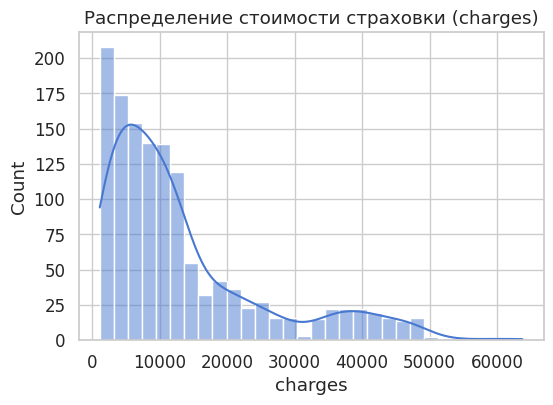

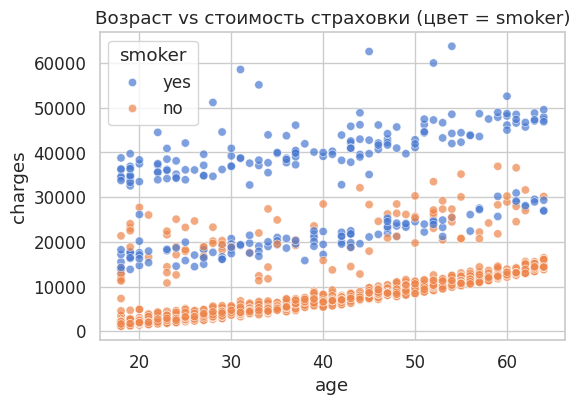

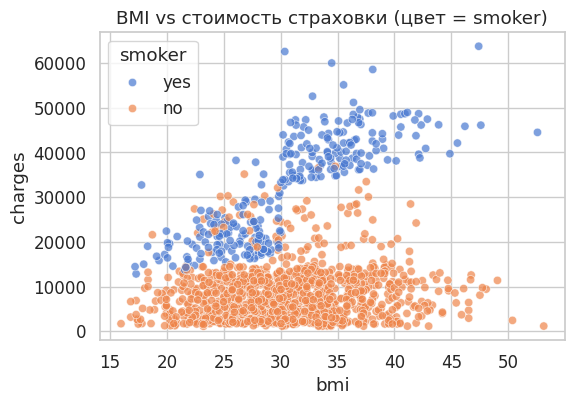

In [ ]:
# Простой EDA: распределение целевой переменной
plt.figure(figsize=(6,4))
sns.histplot(reg_df["charges"], kde=True)
plt.title("Распределение стоимости страховки (charges)")
plt.xlabel("charges")
plt.show()

# Зависимость стоимости от возраста
plt.figure(figsize=(6,4))
sns.scatterplot(data=reg_df, x="age", y="charges", hue="smoker", alpha=0.7)
plt.title("Возраст vs стоимость страховки (цвет = smoker)")
plt.show()

# Зависимость стоимости от BMI
plt.figure(figsize=(6,4))
sns.scatterplot(data=reg_df, x="bmi", y="charges", hue="smoker", alpha=0.7)
plt.title("BMI vs стоимость страховки (цвет = smoker)")
plt.show()

In [ ]:
# Разбиение на признаки (X) и таргет (y)
X_reg = reg_df.drop(columns=["charges"])
y_reg = reg_df["charges"]

# Разделяем на train и test
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("Размер train:", X_reg_train.shape)
print("Размер test:", X_reg_test.shape)

Размер train: (1070, 6)
Размер test: (268, 6)


In [ ]:
X_reg_train

,age,sex,bmi,children,smoker,region
560,46,female,19.950,2,no,northwest
1285,47,female,24.320,0,no,northeast
1142,52,female,24.860,0,no,southeast
969,39,female,34.320,5,no,southeast
486,54,female,21.470,3,no,northwest
...,...,...,...,...,...,...
1095,18,female,31.350,4,no,northeast
1130,39,female,23.870,5,no,southeast
1294,58,male,25.175,0,no,northeast
860,37,female,47.600,2,yes,southwest


In [ ]:
X_reg_train_cat

,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
560,0.0,0.0,1.0,0.0,0.0
1285,0.0,0.0,0.0,0.0,0.0
1142,0.0,0.0,0.0,1.0,0.0
969,0.0,0.0,0.0,1.0,0.0
486,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...
1095,0.0,0.0,0.0,0.0,0.0
1130,0.0,0.0,0.0,1.0,0.0
1294,1.0,0.0,0.0,0.0,0.0
860,0.0,1.0,0.0,0.0,1.0


In [ ]:
# Базовая модель: линейная регрессия с простым препроцессингом
# 1) One-hot кодирование категориальных признаков
reg_cat_cols = X_reg_train.select_dtypes(include=["object"]).columns.tolist()
reg_num_cols = X_reg_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

ohe_reg = OneHotEncoder(drop="first", sparse_output=False)
X_reg_train_cat = pd.DataFrame(
    ohe_reg.fit_transform(X_reg_train[reg_cat_cols]),
    index=X_reg_train.index,
    columns=ohe_reg.get_feature_names_out(reg_cat_cols),
)
X_reg_test_cat = pd.DataFrame(
    ohe_reg.transform(X_reg_test[reg_cat_cols]),
    index=X_reg_test.index,
    columns=ohe_reg.get_feature_names_out(reg_cat_cols),
)

In [ ]:
X_reg_train_num = X_reg_train[reg_num_cols].copy()
X_reg_test_num = X_reg_test[reg_num_cols].copy()

# Собираем финальные таблицы
X_reg_train_base = pd.concat([X_reg_train_num, X_reg_train_cat], axis=1)
X_reg_test_base = pd.concat([X_reg_test_num, X_reg_test_cat], axis=1)

In [ ]:
# создаем модель
lin_reg = LinearRegression()

# обучаем модель
lin_reg.fit(X_reg_train_base, y_reg_train)

LinearRegression()

In [ ]:
# теперь посмотрим на метрики (более конкретно обсудим их на следующем семинаре)
y_reg_train_pred = lin_reg.predict(X_reg_train_base)
y_reg_test_pred = lin_reg.predict(X_reg_test_base)

def print_regression_metrics(y_true_train, y_pred_train, y_true_test, y_pred_test):
    print("Train MAE:", round(mean_absolute_error(y_true_train, y_pred_train), 2))
    print("Test  MAE:", round(mean_absolute_error(y_true_test, y_pred_test), 2))
    print("Train MSE:", round(mean_squared_error(y_true_train, y_pred_train), 2))
    print("Test  MSE:", round(mean_squared_error(y_true_test, y_pred_test), 2))
    print("Train R^2:", round(r2_score(y_true_train, y_pred_train), 2))
    print("Test  R^2:", round(r2_score(y_true_test, y_pred_test), 2))

print("Базовая линейная регрессия")
print_regression_metrics(y_reg_train, y_reg_train_pred, y_reg_test, y_reg_test_pred)

Базовая линейная регрессия
Train MAE: 4208.23
Test  MAE: 4181.19
Train MSE: 37277681.7
Test  MSE: 33596915.85
Train R^2: 0.74
Test  R^2: 0.78


In [ ]:
# Улучшаем модель

# Добавим масштабирование признаков (идея - модель меньше обращала внимание на "Большие" признаки)
scaler_reg = StandardScaler()
X_reg_train_num_scaled = pd.DataFrame(
    scaler_reg.fit_transform(X_reg_train[reg_num_cols]),
    index=X_reg_train.index,
    columns=reg_num_cols,
)
X_reg_test_num_scaled = pd.DataFrame(
    scaler_reg.transform(X_reg_test[reg_num_cols]),
    index=X_reg_test.index,
    columns=reg_num_cols,
)

X_reg_train_full = pd.concat([X_reg_train_num_scaled, X_reg_train_cat], axis=1)
X_reg_test_full = pd.concat([X_reg_test_num_scaled, X_reg_test_cat], axis=1)

# Линейная регрессия с регуляризацией - штрафуем за большие веса. Зачем - поговорим на след семинаре
ridge_reg = Ridge(alpha=1.0, random_state=42)
ridge_reg.fit(X_reg_train_full, y_reg_train)

y_reg_train_pred_ridge = ridge_reg.predict(X_reg_train_full)
y_reg_test_pred_ridge = ridge_reg.predict(X_reg_test_full)

print("Модель Ridge (с масштабированием и регуляризацией)")
print_regression_metrics(y_reg_train, y_reg_train_pred_ridge, y_reg_test, y_reg_test_pred_ridge)

Модель Ridge (с масштабированием и регуляризацией)
Train MAE: 4217.47
Test  MAE: 4193.2
Train MSE: 37280722.09
Test  MSE: 33645393.49
Train R^2: 0.74
Test  R^2: 0.78


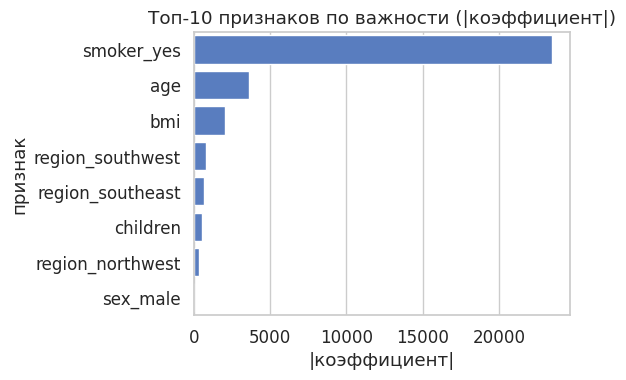

In [ ]:
# Для наглядности посмотрим, какие признаки наиболее важны по модулю коэффициента
coef_series = pd.Series(ridge_reg.coef_, index=X_reg_train_full.columns)
top_features = coef_series.abs().sort_values(ascending=False).head(10)
plt.figure(figsize=(6,4))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Топ-10 признаков по важности (|коэффициент|)")
plt.xlabel("|коэффициент|")
plt.ylabel("признак")
plt.tight_layout()
plt.show()

Наши попытки улучшения не дали прироста в данной задаче, но и особо хуже не сделали.

Что же могло бы положительно повлиять на результат:
- больше данных (чем больше данных, тем больше бы модель могла посмотреть реальных наблюдений и чуть лучше изучить структуру взаимодействия признаков и таргета)
- сбор новых признаков (аналогично расширяем данные)
- генерация признаков из имеющихся (не линейная зависимость, а более хитрая)
- отбор признаков (можно поперебирать признаки или пофильтровать столбцы, удаляя те, которые подсказывают модели ложную связь)
- разделение датасета на сегменты и обучение своей модели для каждого (тут может помочь EDA)

- Как метод Х: взять другие алгоритмы - но это уже на следующем семинаре


## Часть 2. Логистическая регрессия

Задача: предсказать, **подпишется ли клиент на депозит** после маркетинговой кампании.

Датасет: `bank.csv`
- множество признаков о клиенте и контакте
- целевая переменная `y`: `yes` / `no`

In [ ]:
# Загрузка данных для задачи классификации
clf_df = pd.read_csv("bank-full.csv", sep=";")
clf_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
# Быстрый обзор данных
display(clf_df.info())
display(clf_df.describe(include="all"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


None

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,45211.000000,45211,45211,45211,45211,45211.000000,45211,45211,45211,45211.000000,45211,45211.000000,45211.000000,45211.000000,45211.000000,45211,45211
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,9732,27214,23202,44396,NaN,25130,37967,29285,NaN,13766,NaN,NaN,NaN,NaN,36959,39922
mean,40.936210,NaN,NaN,NaN,NaN,1362.272058,NaN,NaN,NaN,15.806419,NaN,258.163080,2.763841,40.197828,0.580323,NaN,NaN
std,10.618762,NaN,NaN,NaN,NaN,3044.765829,NaN,NaN,NaN,8.322476,NaN,257.527812,3.098021,100.128746,2.303441,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-8019.000000,NaN,NaN,NaN,1.000000,NaN,0.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,33.000000,NaN,NaN,NaN,NaN,72.000000,NaN,NaN,NaN,8.000000,NaN,103.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,448.000000,NaN,NaN,NaN,16.000000,NaN,180.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,48.000000,NaN,NaN,NaN,NaN,1428.000000,NaN,NaN,NaN,21.000000,NaN,319.000000,3.000000,-1.000000,0.000000,NaN,NaN


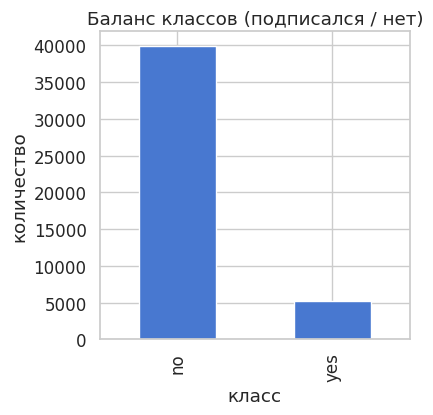

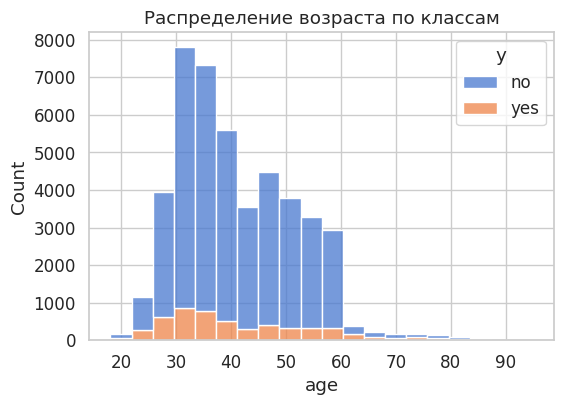

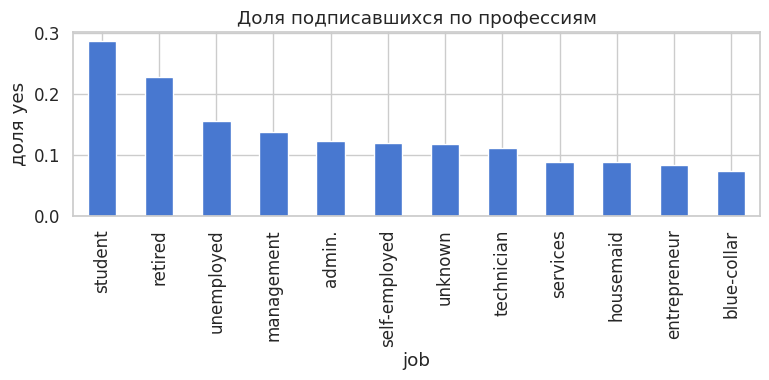

In [ ]:
# Простой EDA: баланс классов и некоторые зависимости
plt.figure(figsize=(4,4))
clf_df["y"].value_counts().plot(kind="bar")
plt.title("Баланс классов (подписался / нет)")
plt.xlabel("класс")
plt.ylabel("количество")
plt.show()

# Распределение возраста по классам
plt.figure(figsize=(6,4))
sns.histplot(data=clf_df, x="age", hue="y", bins=20, kde=False, multiple="stack")
plt.title("Распределение возраста по классам")
plt.show()

# Доля подписавшихся по типу работы
plt.figure(figsize=(8,4))
pd.crosstab(clf_df["job"], clf_df["y"], normalize="index")["yes"].sort_values(ascending=False).plot(kind="bar")
plt.title("Доля подписавшихся по профессиям")
plt.ylabel("доля yes")
plt.tight_layout()
plt.show()

In [ ]:
# Разделяем на признаки и таргет
# Удаляем строки с NaN в целевой переменной перед разделением
clf_df_cleaned = clf_df.dropna(subset=["y"])

X_clf = clf_df_cleaned.drop(columns=["y"])
y_clf = clf_df_cleaned["y"].map({"no": 0, "yes": 1})

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("Размер train:", X_clf_train.shape)
print("Размер test:", X_clf_test.shape)

Размер train: (36168, 16)
Размер test: (9043, 16)


In [ ]:
# Препроцессинг: one-hot для категориальных
clf_cat_cols = X_clf_train.select_dtypes(include=["object"]).columns.tolist()
clf_num_cols = X_clf_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

ohe_clf = OneHotEncoder(drop="first", sparse_output=False)
X_clf_train_cat = pd.DataFrame(
    ohe_clf.fit_transform(X_clf_train[clf_cat_cols]),
    index=X_clf_train.index,
    columns=ohe_clf.get_feature_names_out(clf_cat_cols),
)
X_clf_test_cat = pd.DataFrame(
    ohe_clf.transform(X_clf_test[clf_cat_cols]),
    index=X_clf_test.index,
    columns=ohe_clf.get_feature_names_out(clf_cat_cols),
)

X_clf_train_num = X_clf_train[clf_num_cols].copy()
X_clf_test_num = X_clf_test[clf_num_cols].copy()

X_clf_train_base = pd.concat([X_clf_train_num, X_clf_train_cat], axis=1)
X_clf_test_base = pd.concat([X_clf_test_num, X_clf_test_cat], axis=1)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Базовая логистическая регрессия
Train accuracy: 0.9
Test  accuracy: 0.9


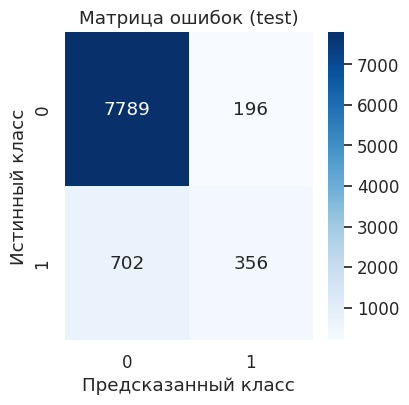

In [ ]:
# Базовая логистическая регрессия


log_reg_base = LogisticRegression(max_iter=1000)
log_reg_base.fit(X_clf_train_base, y_clf_train)

y_clf_train_pred = log_reg_base.predict(X_clf_train_base)
y_clf_test_pred = log_reg_base.predict(X_clf_test_base)

def print_classification_metrics(y_true_train, y_pred_train, y_true_test, y_pred_test):
    print("Train accuracy:", round(accuracy_score(y_true_train, y_pred_train), 2))
    print("Test  accuracy:", round(accuracy_score(y_true_test, y_pred_test), 2))

print("Базовая логистическая регрессия")
print_classification_metrics(y_clf_train, y_clf_train_pred, y_clf_test, y_clf_test_pred)

# Матрица ошибок на тесте
cm = confusion_matrix(y_clf_test, y_clf_test_pred)
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title("Матрица ошибок (test)")
plt.show()